In [1]:
import sys
print(sys.executable)
# LÆG MÆRKE TIL DER ER 2 VERSIONER AF PYTHON 3.11.9. En version hvor Microsoft\WindowsApps er en del af PATH/addresse, 
# og en hvor det ikke er en del af PATH/addresse. Sørg for at vælge den der IKKE inderholder Microsoft/Windows
# (Gælder kun for min Bærbar Computer)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


$$r_{t,t+5}=\frac{close\_future - close\_now}{close\_now}$$

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Write the folder name only once
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0" # HUSK AT VÆLGE DET RIGTIGE MAPPE NAVN

pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

print(df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  future_return_5d
0     FI     2024-04-18      0.491563          0.043428
1    VRT     2024-04-18      0.643166          0.115294
2    HWM     2024-04-19      0.534326          0.047153
3     BN     2024-04-19      0.625872          0.050526
4   AXON     2024-04-22      0.558367          0.066372


In [3]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# Load predictions
# ----------------------------
data_folder = "res_96_color_candlestick_vol_1_ma_1_bb_0_rsi_0"   # choose the right folder
pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

# ----------------------------
# Settings
# ----------------------------
n_groups = 10      # 10 = deciles
holding_days = 5   # R5 horizon

# ----------------------------
# Prepare variables
# ----------------------------
df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

df = df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].dropna().copy()

# If your file contains DAILY rolling predictions, but you want paper-style
# non-overlapping 5-day rebalances, uncomment these 2 lines:
# keep_dates = sorted(df["rebalance_date"].unique())[::holding_days]
# df = df[df["rebalance_date"].isin(keep_dates)].copy()

def assign_groups(probs: pd.Series, n_groups: int = 10) -> pd.Series:
    """
    Assign 1..n_groups within each rebalance date.
    rank(method='first') avoids qcut problems when probabilities tie.
    """
    if probs.notna().sum() < n_groups:
        return pd.Series(np.nan, index=probs.index)

    ranks = probs.rank(method="first")
    groups = pd.qcut(ranks, q=n_groups, labels=False) + 1
    return pd.Series(groups, index=probs.index)

# ----------------------------
# Sort into deciles within each rebalance date
# ----------------------------
df["decile"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(lambda x: assign_groups(x, n_groups=n_groups))
)

df = df.dropna(subset=["decile"]).copy()
df["decile"] = df["decile"].astype(int)

# ----------------------------
# Equal-weight portfolio return for each date x decile
# ----------------------------
period_ret = (
    df.groupby(["rebalance_date", "decile"])["future_return_5d"]
      .mean()
      .unstack("decile")
      .sort_index(axis=1)
)

# keep only dates where all deciles exist
period_ret = period_ret.dropna()

# ----------------------------
# Annualization helpers
# ----------------------------
ann_factor = 252 / holding_days

def annualized_return(x: pd.Series) -> float:
    return x.mean() * ann_factor

def annualized_sharpe(x: pd.Series) -> float:
    s = x.std(ddof=1)
    if pd.isna(s) or s == 0:
        return np.nan
    return (x.mean() / s) * np.sqrt(ann_factor)

# ----------------------------
# Build decile summary table
# ----------------------------
summary = pd.DataFrame({
    "Ret": period_ret.apply(annualized_return),
    "SR": period_ret.apply(annualized_sharpe),
})

# High-minus-Low
hl = period_ret[n_groups] - period_ret[1]
summary.loc["H-L", "Ret"] = annualized_return(hl)
summary.loc["H-L", "SR"]  = annualized_sharpe(hl)

# Optional significance stars for H-L mean return
tstat, pval = stats.ttest_1samp(hl.dropna(), popmean=0.0)
if pval < 0.001:
    stars = "***"
elif pval < 0.01:
    stars = "**"
elif pval < 0.05:
    stars = "*"
else:
    stars = ""

# Rename rows to match the paper style
summary = summary.rename(index={1: "Low", n_groups: "High"})

ordered_rows = ["Low"] + [i for i in range(2, n_groups)] + ["High", "H-L"]
summary = summary.loc[ordered_rows]

# Pretty printed version
table_out = summary.copy().reset_index()
table_out.columns = ["Decile", "Ret", "SR"]
table_out["Decile"] = table_out["Decile"].astype(str)
table_out.loc[table_out["Decile"] == "H-L", "Decile"] = f"H-L{stars}"

table_out["Ret"] = table_out["Ret"].map(lambda x: f"{x:.2f}")
table_out["SR"]  = table_out["SR"].map(lambda x: f"{x:.2f}")

print(table_out.to_string(index=False))

Decile   Ret    SR
   Low  0.15  1.08
     2  0.14  1.15
     3  0.12  0.81
     4  0.27  1.80
     5  0.14  0.95
     6  0.18  1.27
     7  0.11  0.83
     8  0.08  0.60
     9  0.23  1.61
  High  0.11  0.86
   H-L -0.03 -0.38


In [4]:
print(period_ret.mean())
print(hl.mean())

decile
1     0.002911
2     0.002689
3     0.002291
4     0.005327
5     0.002796
6     0.003640
7     0.002281
8     0.001631
9     0.004594
10    0.002251
dtype: float64
-0.0006607695526289315


In [5]:
counts = df.groupby("rebalance_date")["ticker"].nunique()
print(counts.describe())
print(counts.head(20))

count     34.0
mean     391.0
std        0.0
min      391.0
25%      391.0
50%      391.0
75%      391.0
max      391.0
Name: ticker, dtype: float64
rebalance_date
2024-04-24    391
2024-05-01    391
2024-05-08    391
2024-05-15    391
2024-05-22    391
2024-05-30    391
2024-06-06    391
2024-06-13    391
2024-06-21    391
2024-06-28    391
2024-07-08    391
2024-07-15    391
2024-07-22    391
2024-07-29    391
2024-08-05    391
2024-08-12    391
2024-08-19    391
2024-08-26    391
2024-09-03    391
2024-09-10    391
Name: ticker, dtype: int64


In [6]:
decile_counts = df.groupby(["rebalance_date", "decile"])["ticker"].nunique().unstack()
print(decile_counts.head())
print(decile_counts.describe())

decile          1   2   3   4   5   6   7   8   9   10
rebalance_date                                        
2024-04-24      40  39  39  39  39  39  39  39  39  39
2024-05-01      40  39  39  39  39  39  39  39  39  39
2024-05-08      40  39  39  39  39  39  39  39  39  39
2024-05-15      40  39  39  39  39  39  39  39  39  39
2024-05-22      40  39  39  39  39  39  39  39  39  39
decile    1     2     3     4     5     6     7     8     9     10
count   34.0  34.0  34.0  34.0  34.0  34.0  34.0  34.0  34.0  34.0
mean    40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0
std      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
min     40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0
25%     40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0
50%     40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0
75%     40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0
max     40.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0  39.0


In [7]:
n_groups = 10   # use 10 in final analysis

In [8]:
def assign_groups(prob_series):
    if len(prob_series) < n_groups:
        return pd.Series([np.nan] * len(prob_series), index=prob_series.index)

    ranked = prob_series.rank(method="first")

    return pd.qcut(
        ranked,
        q=n_groups,
        labels=False
    ) + 1

df["group"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(assign_groups)
)

df = df.dropna(subset=["group"]).copy()
df["group"] = df["group"].astype(int)

print(df[["ticker", "rebalance_date", "pred_prob_up", "group", "future_return_5d"]].head())

   ticker rebalance_date  pred_prob_up  group  future_return_5d
9     IAU     2024-04-24      0.582168      8         -0.003876
10    IRM     2024-04-24      0.457326      2         -0.001151
11    EIX     2024-04-24      0.523309      5          0.006495
12   KLAC     2024-04-24      0.561756      7          0.014470
13    CNQ     2024-04-24      0.530701      6         -0.025484


In [9]:
portfolio_returns = (
    df.groupby(["rebalance_date", "group"])["future_return_5d"]
      .mean()
      .reset_index()
)

print(portfolio_returns.head())

  rebalance_date  group  future_return_5d
0     2024-04-24      1         -0.011325
1     2024-04-24      2         -0.016258
2     2024-04-24      3         -0.009402
3     2024-04-24      4         -0.012081
4     2024-04-24      5         -0.017969


In [10]:
portfolio_wide = portfolio_returns.pivot(
    index="rebalance_date",
    columns="group",
    values="future_return_5d"
)

portfolio_wide.columns = [f"G{int(c)}" for c in portfolio_wide.columns]

low_col = "G1"
high_col = f"G{n_groups}"

portfolio_wide["H-L"] = portfolio_wide[high_col] - portfolio_wide[low_col]

print(portfolio_wide.head())

                      G1        G2        G3        G4        G5        G6  \
rebalance_date                                                               
2024-04-24     -0.011325 -0.016258 -0.009402 -0.012081 -0.017969 -0.019632   
2024-05-01      0.027393  0.024899  0.025880  0.034641  0.026160  0.031622   
2024-05-08      0.017967  0.022113  0.018786  0.023024  0.024132  0.030897   
2024-05-15      0.000400  0.001146 -0.000059 -0.003778 -0.007165 -0.001783   
2024-05-22     -0.021490 -0.015808 -0.020053 -0.018608 -0.008188 -0.014421   

                      G7        G8        G9       G10       H-L  
rebalance_date                                                    
2024-04-24     -0.008328 -0.016055  0.005435 -0.004721  0.006604  
2024-05-01      0.026445  0.024563  0.033023  0.020153 -0.007240  
2024-05-08      0.020377  0.030206  0.019116  0.015713 -0.002255  
2024-05-15     -0.010945 -0.006763 -0.000504 -0.008273 -0.008673  
2024-05-22     -0.023022 -0.025882 -0.019910 -0.028

In [11]:
periods_per_year = 252 / 5

def annualized_return(r):
    return r.mean() * periods_per_year

def annualized_sharpe(r):
    std = r.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return (r.mean() / std) * np.sqrt(periods_per_year)

def p_value_mean_zero(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    t_stat, p_val = stats.ttest_1samp(r, popmean=0.0, nan_policy="omit")
    return p_val

def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary_rows = []

for g in range(1, n_groups + 1):
    col = f"G{g}"
    r = portfolio_wide[col].dropna()

    if g == 1:
        label = "Low"
    elif g == n_groups:
        label = "High"
    else:
        label = str(g)

    p = p_value_mean_zero(r)

    summary_rows.append({
        "Group": label,
        "Ret": annualized_return(r),
        "SR": annualized_sharpe(r),
        "p_value": p,
        "stars": stars_from_p(p)
    })

# Add H-L
r_hl = portfolio_wide["H-L"].dropna()
p_hl = p_value_mean_zero(r_hl)

summary_rows.append({
    "Group": "H-L",
    "Ret": annualized_return(r_hl),
    "SR": annualized_sharpe(r_hl),
    "p_value": p_hl,
    "stars": stars_from_p(p_hl)
})

summary_table = pd.DataFrame(summary_rows)

summary_table["Ret"] = summary_table["Ret"].round(2)
summary_table["SR_display"] = summary_table["SR"].map(lambda x: f"{x:.2f}") + summary_table["stars"]

print(summary_table[["Group", "Ret", "SR_display", "p_value"]].to_string(index=False))

Group   Ret SR_display  p_value
  Low  0.15       1.08 0.380204
    2  0.14       1.15 0.352632
    3  0.12       0.81 0.511973
    4  0.27       1.80 0.149288
    5  0.14       0.95 0.438621
    6  0.18       1.27 0.305626
    7  0.11       0.83 0.498347
    8  0.08       0.60 0.627732
    9  0.23       1.61 0.194115
 High  0.11       0.86 0.486886
  H-L -0.03      -0.38 0.758604


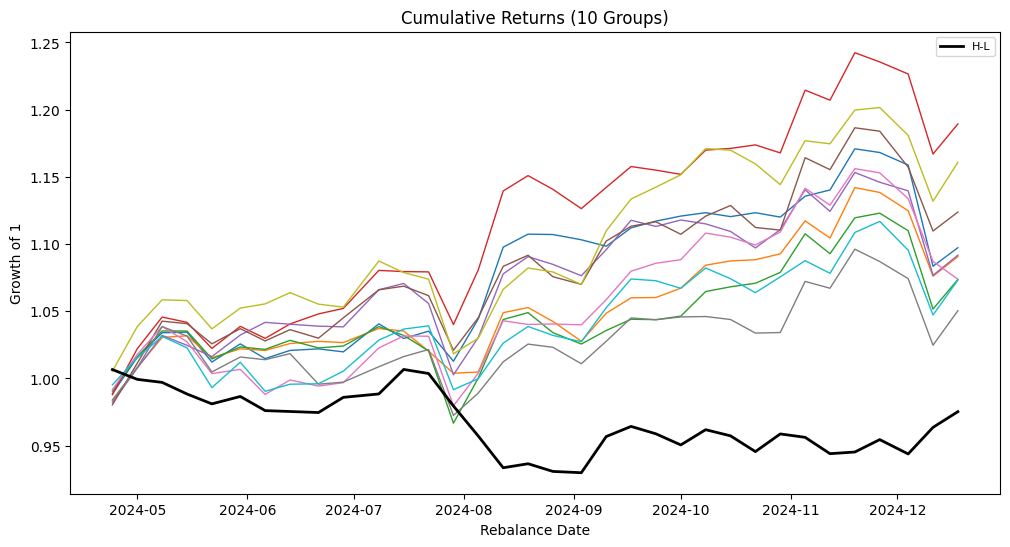

In [12]:
cum_df = (1 + portfolio_wide.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(cum_df.index, cum_df[f"G{g}"], linewidth=1)

plt.plot(cum_df.index, cum_df["H-L"], linewidth=2, color="black", label="H-L")

plt.title(f"Cumulative Returns ({n_groups} Groups)")
plt.ylabel("Growth of 1")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()

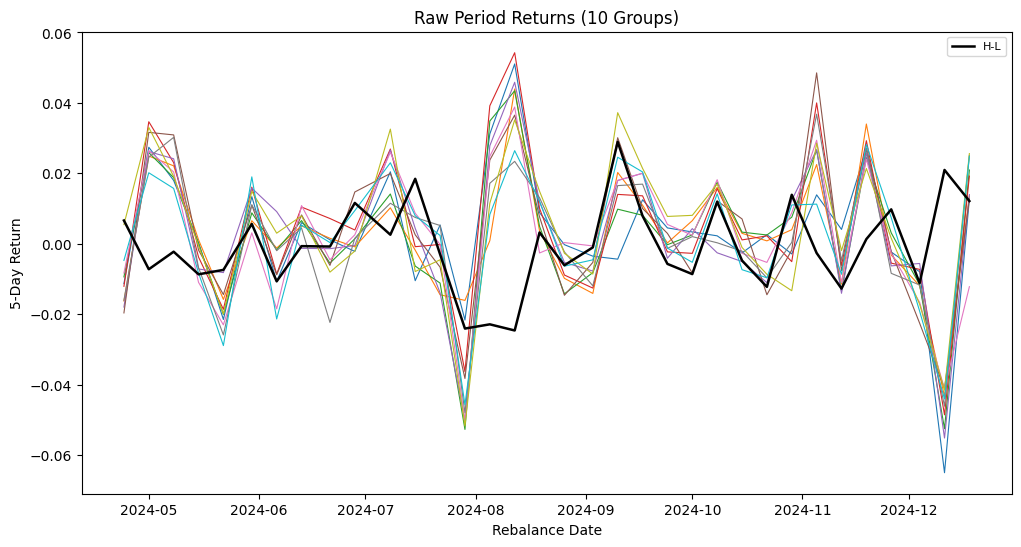

In [13]:
plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(portfolio_wide.index, portfolio_wide[f"G{g}"], linewidth=0.8)

plt.plot(portfolio_wide.index, portfolio_wide["H-L"], linewidth=1.8, color="black", label="H-L")

plt.title(f"Raw Period Returns ({n_groups} Groups)")
plt.ylabel("5-Day Return")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()